In [1]:
import numpy as np           
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-03-Random-Forest\bank-additional-full.csv',sep=';')
print(df.shape)
df.info()
print(df.head(10))
df.describe()

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df.isnull().sum()
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n====={col}=====")
    print(df[col].value_counts())


=====job=====
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

=====marital=====
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

=====education=====
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

=====default=====
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

=====housing=====
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

=====loan=====
loan
no         33950
yes         6248
un

In [6]:
from sklearn.model_selection import train_test_split

df_data = df.drop(columns=['duration']).copy()
df_data['pdays_never_contacted'] = (df_data['pdays'] == 999).astype(int)
df_data['pdays'] = df_data['pdays'].replace(999, -1)

X = df_data.drop(columns=['y'])
X = pd.get_dummies(X, drop_first=True)
y = df_data['y'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Số khách chưa từng liên hệ:', df_data['pdays_never_contacted'].sum())
print('Tỷ lệ yes trong train:', y_train.mean())

X_train: (32950, 53)
X_test: (8238, 53)
Số khách chưa từng liên hệ: 39673
Tỷ lệ yes trong train: 0.11265553869499241


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=400,
    max_features='sqrt',
    class_weight='balanced_subsample',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print(f'OOB score: {rf.oob_score_:.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_proba):.4f}')
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

OOB score: 0.8918
ROC-AUC: 0.7844
PR-AUC: 0.4331

Confusion matrix:
[[7107  203]
 [ 660  268]]

Classification report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7310
         yes       0.57      0.29      0.38       928

    accuracy                           0.90      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



In [8]:
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier


def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    probabilities = model.predict_proba(X_test_data)[:, 1]
    return roc_auc_score(y_test_data, probabilities), average_precision_score(y_test_data, probabilities)


X_leak = pd.get_dummies(df.drop(columns=['y']), drop_first=True)
X_leak_train, X_leak_test, y_leak_train, y_leak_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42, stratify=y
)

rf_leak = RandomForestClassifier(
    n_estimators=200, max_features='sqrt', class_weight='balanced_subsample',
    n_jobs=-1, random_state=42
)
leak_auc, leak_pr_auc = evaluate_model(
    rf_leak, X_leak_train, X_leak_test, y_leak_train, y_leak_test
)

print('So sánh rò rỉ duration:')
print(f'Không duration - ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Có duration    - ROC-AUC: {leak_auc:.4f}')
print('duration chỉ biết sau cuộc gọi, vì vậy không được dùng khi triển khai.')

models = {
    'Dummy': DummyClassifier(strategy='prior', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': rf
}
comparison = []
for model_name, model in models.items():
    model_auc, model_pr_auc = evaluate_model(model, X_train, X_test, y_train, y_test)
    comparison.append({'model': model_name, 'roc_auc': model_auc, 'pr_auc': model_pr_auc})
print('\nSo sánh mô hình:')
print(pd.DataFrame(comparison).round(4))

k = min(5000, len(y_test))
top_indices = np.argsort(y_proba)[-k:]
precision_at_k = y_test.iloc[top_indices].mean()
lift_at_k = precision_at_k / y_test.mean()
print(f'\nPrecision@{k}: {precision_at_k:.4f}')
print(f'Lift@{k}: {lift_at_k:.2f}x')

permutation = permutation_importance(
    rf, X_test, y_test, n_repeats=5, scoring='average_precision', random_state=42, n_jobs=-1
)
importance = pd.Series(permutation.importances_mean, index=X_test.columns)
print('\nTop 15 permutation importance:')
print(importance.sort_values(ascending=False).head(15))

So sánh rò rỉ duration:
Không duration - ROC-AUC: 0.7844
Có duration    - ROC-AUC: 0.9493
duration chỉ biết sau cuộc gọi, vì vậy không được dùng khi triển khai.

So sánh mô hình:
           model  roc_auc  pr_auc
0          Dummy   0.5000  0.1126
1  Decision Tree   0.7892  0.4481
2  Random Forest   0.7844  0.4331

Precision@5000: 0.1584
Lift@5000: 1.41x

Top 15 permutation importance:
pdays                    0.045362
nr.employed              0.039331
pdays_never_contacted    0.033645
poutcome_success         0.029814
emp.var.rate             0.016368
euribor3m                0.016003
contact_telephone        0.009459
campaign                 0.006834
month_oct                0.005020
poutcome_nonexistent     0.003387
housing_yes              0.003012
previous                 0.002629
loan_yes                 0.001444
month_mar                0.000533
education_basic.6y       0.000523
dtype: float64


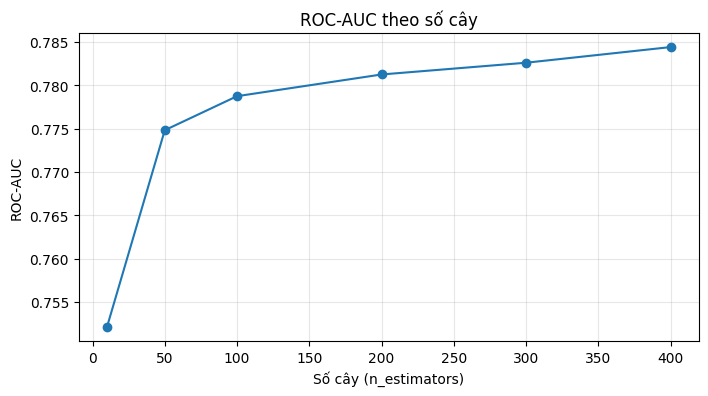

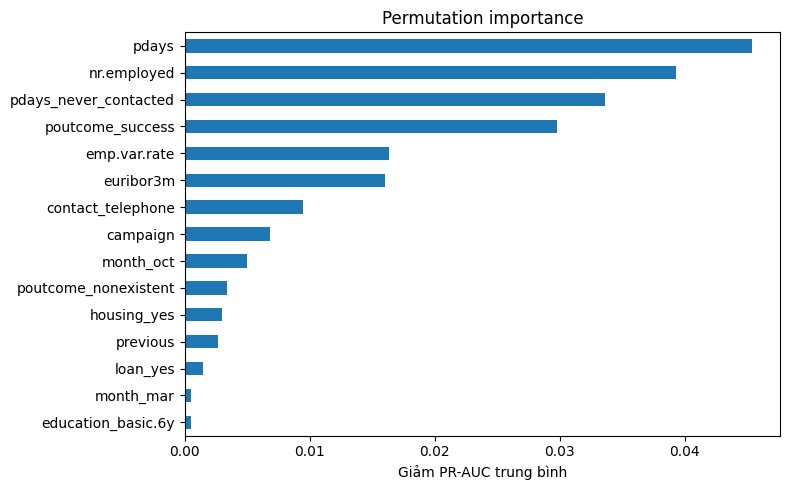

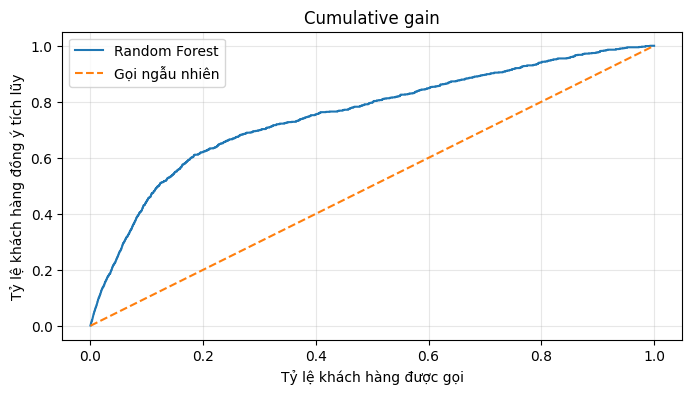

Đã lưu 5000 khách hàng vào outputs\danh_sach_goi_top5000.csv


In [9]:
from pathlib import Path

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)

estimators_grid = [10, 50, 100, 200, 300, 400]
auc_scores = []
for estimator_count in estimators_grid:
    model = RandomForestClassifier(
        n_estimators=estimator_count, max_features='sqrt',
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    )
    model.fit(X_train, y_train)
    auc_scores.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

plt.figure(figsize=(8, 4))
plt.plot(estimators_grid, auc_scores, marker='o')
plt.xlabel('Số cây (n_estimators)')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC theo số cây')
plt.grid(alpha=0.3)
plt.show()

importance.sort_values(ascending=True).tail(15).plot.barh(figsize=(8, 5), title='Permutation importance')
plt.xlabel('Giảm PR-AUC trung bình')
plt.tight_layout()
plt.show()

sorted_indices = np.argsort(y_proba)[::-1]
cumulative_positives = np.cumsum(y_test.iloc[sorted_indices].to_numpy())
contacted = np.arange(1, len(y_test) + 1)
cumulative_gain = cumulative_positives / y_test.sum()
random_gain = contacted / len(y_test)

plt.figure(figsize=(8, 4))
plt.plot(contacted / len(y_test), cumulative_gain, label='Random Forest')
plt.plot(contacted / len(y_test), random_gain, '--', label='Gọi ngẫu nhiên')
plt.xlabel('Tỷ lệ khách hàng được gọi')
plt.ylabel('Tỷ lệ khách hàng đồng ý tích lũy')
plt.title('Cumulative gain')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ranked_customers = df.loc[X_test.index].copy()
ranked_customers['predicted_probability'] = y_proba
ranked_customers = ranked_customers.sort_values('predicted_probability', ascending=False)
ranked_customers.head(k).to_csv(output_dir / 'danh_sach_goi_top5000.csv', index=False)
print(f'Đã lưu {min(k, len(ranked_customers))} khách hàng vào {output_dir / "danh_sach_goi_top5000.csv"}')